# 살펴보기

<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#데이터-분포" data-toc-modified-id="데이터-분포-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>데이터 분포</a></span></li><li><span><a href="#지표-설정" data-toc-modified-id="지표-설정-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>지표 설정</a></span></li></ul></div>

In [1]:
# import os
# import random #데이터 샘플링
# from collections import Counter # count 용도

import numpy as np
import pandas as pd

# from geopy import distance # 거리 계산
# import geopy.distance
from tqdm import tqdm

import warnings
warnings.filterwarnings('ignore')

# 시각화
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
plt.style.use('fivethirtyeight')

# 한글, 마이너스 깨짐 방지
from matplotlib import rc, font_manager, rcParams
font=font_manager.FontProperties(fname="c:/Windows/Fonts/malgun.ttf").get_name()
rc('font', family = font)
rcParams['axes.unicode_minus'] = False

# import folium # 지도 관련 시각화
# from folium.plugins import MarkerCluster #지도 관련 시각화

In [4]:
df = pd.read_csv('./source/restaurant_cleaning(mk).csv')
df.head()

,name,category,address,score,eval_cnt,review_cnt,lat,lng,distance
0,아리차이 신림점,중화요리,신림동 1430-11,3.8,64,45,37.487588,126.928260,388.576625
1,디자이너리카페,카페,신림동 1465-12,3.6,33,184,37.485008,126.924088,497.792949
2,원조민속순대타운,순대,신림동 1640-31,3.3,30,175,37.483252,126.928758,138.279774
3,월화고기 보라매직영점,"육류,고기",봉천동 732-3,4.2,103,215,37.491585,126.926289,865.557687
4,막불감동 신림본점,냉면,신림동 1433-60,3.7,41,97,37.484256,126.928156,132.134471


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 495 entries, 0 to 494
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   name        495 non-null    object 
 1   category    495 non-null    object 
 2   address     495 non-null    object 
 3   score       495 non-null    float64
 4   eval_cnt    495 non-null    int64  
 5   review_cnt  495 non-null    int64  
 6   lat         495 non-null    float64
 7   lng         495 non-null    float64
 8   distance    495 non-null    float64
dtypes: float64(4), int64(2), object(3)
memory usage: 34.9+ KB


## 데이터 분포

+ 데이터의 분포 살펴보기

In [6]:
df.describe()

,score,eval_cnt,review_cnt,lat,lng,distance
count,495.000000,495.000000,495.000000,495.000000,495.000000,495.000000
mean,3.424646,10.187879,35.694949,37.485893,126.928172,388.325935
std,1.246208,12.389065,50.939174,0.003155,0.002856,291.813525
min,0.000000,0.000000,0.000000,37.479269,126.913791,50.034772
25%,2.700000,3.000000,8.000000,37.483481,126.926800,174.016800
50%,3.700000,7.000000,19.000000,37.485048,126.928255,277.047107
75%,4.400000,12.000000,40.000000,37.487471,126.929587,535.674673
max,5.000000,118.000000,580.000000,37.499147,126.938708,1720.410904


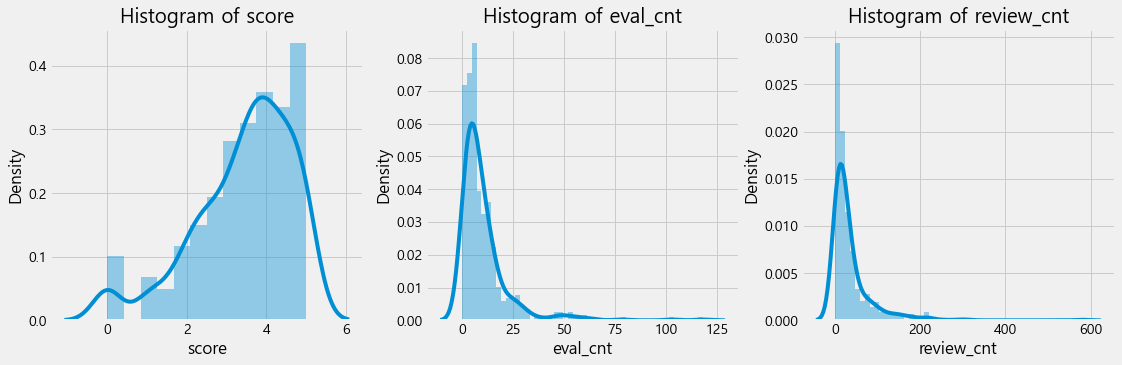

In [23]:
f, ax = plt.subplots(1, 3, figsize=(17, 5))
sns.distplot(df.score, ax=ax[0])
ax[0].set_title('Histogram of score')
sns.distplot(df.eval_cnt, ax=ax[1])
ax[1].set_title('Histogram of eval_cnt')
sns.distplot(df.review_cnt, ax=ax[2])
ax[2].set_title('Histogram of review_cnt')
plt.show()

In [10]:
sum(df.eval_cnt==0) / len(df)

0.04242424242424243

+ 평가가 이루어지지 않은 음식점이 약 4%, 21개.

In [17]:
# 평가가 0개인 음식점
print('평가가 0개인 음식점 개수 :', len(df[df['eval_cnt']==0]))
df[df['eval_cnt']==0]

평가가 0개인 음식점 개수 : 21


,name,category,address,score,eval_cnt,review_cnt,lat,lng,distance
178,시부야38 신림본점,일본식주점,신림동 1640-30,0.0,0,31,37.483414,126.928558,135.847169
197,옛골맛족발 신림직영점,"족발,보쌈",신림동 1430-48,0.0,0,7,37.487471,126.927766,392.642720
199,포차끝판왕,실내포장마차,신림동 1638-19,0.0,0,155,37.482861,126.929527,157.412763
255,신림한우,설렁탕,신림동 1424-19,0.0,0,34,37.485945,126.929934,187.597017
296,발빠닭 신림역점,닭요리,신림동 1640-26,0.0,0,31,37.483784,126.928872,87.771409
326,땡초우동 신림점,"돈까스,우동",신림동 1434-18,0.0,0,4,37.484952,126.927644,192.716564
338,짱형제곱창,"곱창,막창",신림동 1430-51,0.0,0,52,37.487401,126.927442,398.850901
342,이디야커피 신림중앙점,커피전문점,신림동 1433-141,0.0,0,2,37.484299,126.926614,268.178648
348,미식한잔,"호프,요리주점",신림동 1640-23,0.0,0,31,37.483677,126.929074,83.617706
352,가장맛있는족발 신림점,"족발,보쌈",신림동 1431-43,0.0,0,6,37.487297,126.928151,361.522995


+ 평가가 이루어지지 않은 음식점이 약 4%, 21개.
+ 생각보다 허수가 많지 않다. 필터링이 필요할까?
+ 일단 평가 수가 1이상인 곳을 살펴보자

In [20]:
df[df.eval_cnt!=0].describe()

,score,eval_cnt,review_cnt,lat,lng,distance
count,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000
mean,3.576371,10.639241,35.713080,37.485947,126.928170,395.571602
std,1.038371,12.469609,50.887659,0.003193,0.002906,294.842433
min,1.000000,1.000000,0.000000,37.479269,126.913791,50.034772
25%,2.925000,4.000000,8.000000,37.483489,126.926771,177.213711
50%,3.700000,7.000000,19.000000,37.485093,126.928222,280.795050
75%,4.400000,12.750000,40.000000,37.487648,126.929644,539.514784
max,5.000000,118.000000,580.000000,37.499147,126.938708,1720.410904


+ 큰 변화가 있지는 않았다.

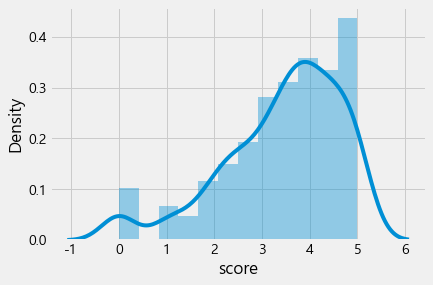

In [22]:
sns.distplot(df.score)
plt.show()

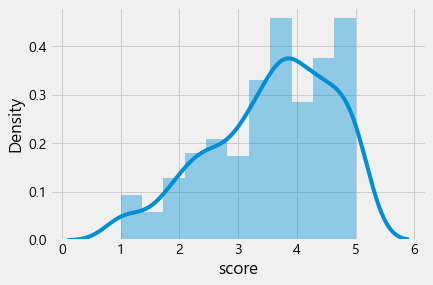

In [25]:
sns.distplot(df[df.eval_cnt!=0].score)
plt.show()

+ 분포를 봤을 때 3점이상 평가를 받은 곳이 더 많음을 알 수 있다.

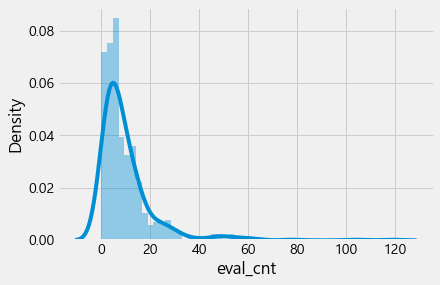

In [27]:
sns.distplot(df.eval_cnt)
plt.show()

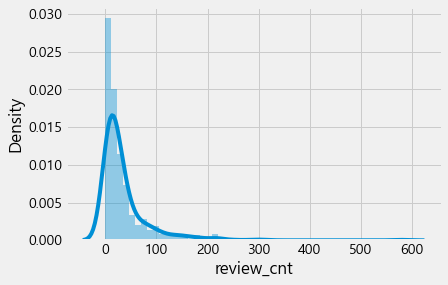

In [28]:
sns.distplot(df.review_cnt)
plt.show()

+ 리뷰와 평가는 여전히 긴 꼬리 분포를 그리고 있다.

In [33]:
df[df['eval_cnt']>3]

,name,category,address,score,eval_cnt,review_cnt,lat,lng,distance
0,아리차이 신림점,중화요리,신림동 1430-11,3.8,64,45,37.487588,126.928260,388.576625
1,디자이너리카페,카페,신림동 1465-12,3.6,33,184,37.485008,126.924088,497.792949
2,원조민속순대타운,순대,신림동 1640-31,3.3,30,175,37.483252,126.928758,138.279774
3,월화고기 보라매직영점,"육류,고기",봉천동 732-3,4.2,103,215,37.491585,126.926289,865.557687
4,막불감동 신림본점,냉면,신림동 1433-60,3.7,41,97,37.484256,126.928156,132.134471
...,...,...,...,...,...,...,...,...,...
490,빽다방 신림역2호점,커피전문점,신림동 1641-12,3.8,5,3,37.482939,126.930123,153.981065
491,궁중 삼계탕,삼계탕,신대방동 395-66,3.2,6,5,37.491395,126.923403,965.021609
492,본죽 신림역점,죽,신림동 1637-3,2.6,9,3,37.481983,126.929644,254.593116
493,고고즉석떡볶이 신림역점,분식,신림동 1424-9,4.5,4,13,37.486187,126.929550,213.112908


In [34]:
df[df['eval_cnt']==1]

,name,category,address,score,eval_cnt,review_cnt,lat,lng,distance
110,동해안회집,회,신림동 1432-63,5.0,1,2,37.485996,126.928594,213.210798
126,숯총각닭발꼼장어,치킨,신림동 1432-137,5.0,1,19,37.485893,126.927781,244.447693
134,홍대몬스터피자 신림점,피자,신림동 1425-11,4.0,1,25,37.486483,126.929583,245.887253
137,매갈,갈비,신림동 1439-13,3.0,1,38,37.487212,126.926461,431.471704
163,독특하개,애견카페,신림동 1438-13,5.0,1,9,37.486851,126.926148,421.752164
182,넥스트에디션 신림점,테마카페,신림동 1640-1,5.0,1,71,37.483737,126.928326,131.372627
189,단골손님 신림점,"호프,요리주점",신림동 1640-36,1.0,1,37,37.483412,126.929161,105.080969
201,꼬주막,한식,신림동 1433-69,2.0,1,83,37.484730,126.927767,174.016800
209,1943,"호프,요리주점",신림동 1640-13,2.0,1,7,37.483659,126.929423,71.213467
295,찬,일본식주점,신림동 1432-176,1.0,1,24,37.487243,126.927955,362.729125


+ 평가가 0개 또는 1개인 음식점들이 생각보다 많지 않았고, 리뷰가 많은 음식점도 있었다.

<AxesSubplot:xlabel='eval_cnt', ylabel='Density'>

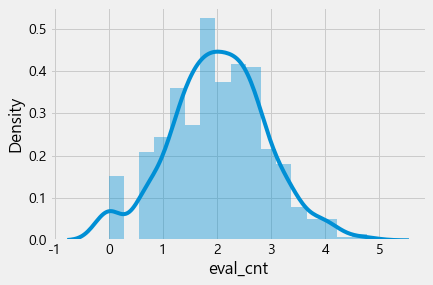

In [65]:
sns.distplot(np.log(df.eval_cnt+1))

<AxesSubplot:xlabel='review_cnt', ylabel='Density'>

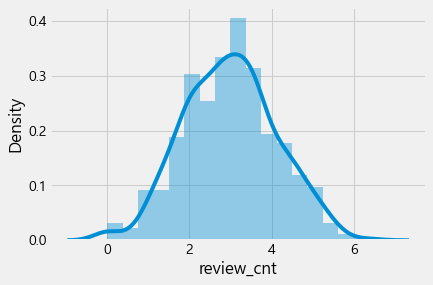

In [41]:
sns.distplot(np.log(df.review_cnt+1))

+ 로그를 취해주면 eval_cnt와 review_cnt는 정규분포와 유사해진다.

## 지표 설정
* eval_cnt와 score, review_cnt를 잘 조합하여 하나의 지표로 만들면 평가에 용이하겠다.


$$JMS = score * log(eval\_cnt+1) + log(review\_cnt+1)$$


+ 위의 공식으로 JMS를 구하였다.
    - $score * log(eval\_cnt+1)$
        * 별점을 단순히 평가 수와 곱하면, 평점이 낮더라도 평가만 많이 받으면 좋은 점수를 받게된다.
        * 또한, eval_cnt의 데이터 스케일이 크고, 분포 내 왜도도 커서 log를 취하여 곱했다.
    - $log(review\_cnt+1)$
        * 리뷰 수는 가산점 개념으로 생각했다.
        * 평점이 비슷한 음식점이 두 곳 있으면, 리뷰가 많은 곳이 가산점을 받을 수 있도록 설계했다.
        * 리뷰 수가 정규분포에 유사할 수 있도록 log값을 취해준 후 스케일링을 진행하였다.

+ JMS를 구한 이후, 이를 0~10 범위에 오도록 스케일링하였다.

In [78]:
df.score * np.log(df.eval_cnt+1)

0      15.862672
1      12.694898
2      11.332158
3      19.506442
4      13.829378
         ...    
490     6.808686
491     6.226912
492     5.986721
493     7.242471
494    10.397208
Length: 495, dtype: float64

In [79]:
max(np.log(df.review_cnt+1))

6.364750756851911

In [58]:
min(np.log(df.review_cnt+1))

0.0

In [86]:
# 별점과 log(평가 수+1)를 곱한 뒤, log(review_cnt+1)을 더해준다.
df['JMS'] = (df.score * np.log(df.eval_cnt+1)) + np.log(df.review_cnt+1)

# JMS를 0~10의 번위로 스케일링
df['JMS'] = round(df.JMS / max(df.JMS) * 10, 2)

df.head()

,name,category,address,score,eval_cnt,review_cnt,lat,lng,distance,JMS
0,아리차이 신림점,중화요리,신림동 1430-11,3.8,64,45,37.487588,126.928260,388.576625,7.91
1,디자이너리카페,카페,신림동 1465-12,3.6,33,184,37.485008,126.924088,497.792949,7.20
2,원조민속순대타운,순대,신림동 1640-31,3.3,30,175,37.483252,126.928758,138.279774,6.63
3,월화고기 보라매직영점,"육류,고기",봉천동 732-3,4.2,103,215,37.491585,126.926289,865.557687,10.00
4,막불감동 신림본점,냉면,신림동 1433-60,3.7,41,97,37.484256,126.928156,132.134471,7.40


In [101]:
df_JMS = df.sort_values('JMS', ascending=False).reset_index(drop=True)
df_JMS.head(20)

,name,category,address,score,eval_cnt,review_cnt,lat,lng,distance,JMS
0,월화고기 보라매직영점,"육류,고기",봉천동 732-3,4.2,103,215,37.491585,126.926289,865.557687,10.00
1,신림춘천집 본점,닭요리,신림동 1640-28,4.6,78,57,37.483578,126.928734,112.006133,9.71
2,정담은보쌈 신림점,"족발,보쌈",봉천동 959-4,4.3,54,123,37.485180,126.935330,510.913872,8.86
3,모스키친,"돈까스,우동",신대방동 344-15,4.2,56,101,37.497496,126.927648,1481.007286,8.68
4,서일순대국,순대,신대방동 377-1,3.4,118,175,37.498030,126.920730,1720.410904,8.61
5,시간을들이다,"제과,베이커리",상도동 304-12,4.3,46,115,37.497615,126.930479,1485.364131,8.56
6,서울갈비 신림점,갈비,신림동 1410-17,4.2,48,137,37.484946,126.933579,354.399925,8.55
7,중화요리팔공,중화요리,신림동 10-621,4.3,47,80,37.484043,126.937085,656.213449,8.46
8,포말커피,카페,신림동 1432-119,4.7,27,148,37.485752,126.927855,228.549992,8.31
9,마뇨떡볶이,떡볶이,신림동 1638-1,4.1,46,100,37.482200,126.928909,239.660284,8.20


In [93]:
df_JMS.JMS.describe()

count    495.000000
mean       4.072626
std        1.704032
min        0.440000
25%        2.905000
50%        3.960000
75%        5.135000
max       10.000000
Name: JMS, dtype: float64

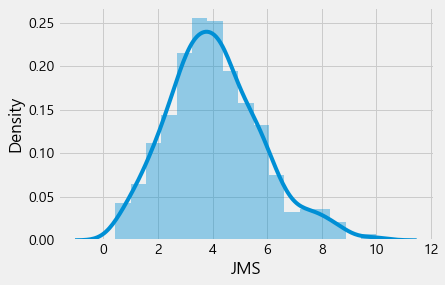

In [95]:
sns.distplot(df_JMS.JMS)
plt.show()

+ 아주 만족스러운 모양이 나왔다.

In [97]:
df_JMS.to_csv('./source/restaurant_JMS.csv', index=False)

In [98]:
pd.read_csv('./source/restaurant_JMS.csv')

,name,category,address,score,eval_cnt,review_cnt,lat,lng,distance,JMS
0,월화고기 보라매직영점,"육류,고기",봉천동 732-3,4.2,103,215,37.491585,126.926289,865.557687,10.00
1,신림춘천집 본점,닭요리,신림동 1640-28,4.6,78,57,37.483578,126.928734,112.006133,9.71
2,정담은보쌈 신림점,"족발,보쌈",봉천동 959-4,4.3,54,123,37.485180,126.935330,510.913872,8.86
3,모스키친,"돈까스,우동",신대방동 344-15,4.2,56,101,37.497496,126.927648,1481.007286,8.68
4,서일순대국,순대,신대방동 377-1,3.4,118,175,37.498030,126.920730,1720.410904,8.61
...,...,...,...,...,...,...,...,...,...,...
490,청춘포차 신림역점,실내포장마차,신림동 1639-2,1.0,1,2,37.483636,126.927342,215.894632,0.72
491,땡초우동 신림점,"돈까스,우동",신림동 1434-18,0.0,0,4,37.484952,126.927644,192.716564,0.65
492,청담육회,"호프,요리주점",신림동 1640-33,0.0,0,4,37.483381,126.928829,123.027020,0.65
493,김채원24시감자탕,감자탕,봉천동 702-3,1.0,1,1,37.490212,126.927838,679.589168,0.56
